# Check LED states
This notebook is used to inspect LED state data stored in a pickle file. The LED states indicate whether the LED was detected as ON or OFF for each video frame. This is useful for checking whether LED onset detection worked correctly and for identifying the first and last LED ON moments in each video.
This code is partially adapted from M. Ronde’s code.

## 0. Import libraries and functions

In [4]:
import pickle
import matplotlib.pyplot as plt

from mrondes_files.helper_functions import select_file

## 1. Open pickle file with LED states

In [5]:
pickle_path = select_file("Select pickle file with LED states you want to check", filetypes=(("Pickle files", "*.pkl"), ("Pickle files", "*.pickle"), ("All files", "*.*")))

# Open and load the pickle file
with open(pickle_path, "rb") as f:
    led_states = pickle.load(f)

## 2. Check keys in file

In [8]:
print("Video keys in pickle:")
for key in led_states.keys():
    print(key)

Video keys in pickle:
3CHT_D1_9000 Video 1 19-3-2025 10_20_02 1.mp4
3CHT_D1_8997 Video 1 19-3-2025 09_53_46 1.mp4
3CHT_D3_8992 Video 1 21-3-2025 09_17_09 1.mp4
3CHT_D2_8997 Video 1 20-3-2025 10_11_12 1.mp4
3CHT_D3_9000 Video 1 21-3-2025 10_32_51 1.mp4
3CHT_D1_8992 Video 1 19-3-2025 09_07_16 1.mp4
3CHT_D3_8997 Video 1 21-3-2025 10_07_00 1.mp4
3CHT_D1_8985 Video 1 19-3-2025 09_30_37 1.mp4
3CHT_D2_8985 Video 1 20-3-2025 09_45_50 1.mp4
3CHT_D2_8992 Video 1 20-3-2025 09_29_34 1.mp4
3CHT_D2_9000 Video 1 20-3-2025 10_34_28 1.mp4
3CHT_D3_8985 Video 1 21-3-2025 09_36_31 1.mp4
3CHT_D3_8997_1 Video 1 21-3-2025 10_08_09 1.mp4
3CHT_D3_8985 Video 1 21-3-2025 09_38_06 1.mp4


## 3. Check an entry

In [13]:
example_key = list(led_states.keys())[10]
print(f"\n Example entry for {example_key}:\n", led_states[example_key])


 Example entry for 3CHT_D2_9000 Video 1 20-3-2025 10_34_28 1.mp4:
 [0 0 0 ... 0 0 0]


## 4. Check first 10 states of an example key

In [14]:
if example_key in led_states:
    states = led_states[example_key]
    fps = 30  # ⚠️ replace with your actual video FPS

    timestamps = [i / fps for i in range(len(states))]

    print(f"# LED states: {len(states)}")
    print("First 10 states:", states[:10])
else:
    print(f"{video_key} not found in led_states")

# LED states: 18332
First 10 states: [0 0 0 0 0 0 0 0 0 0]


## 5. Visually check example key

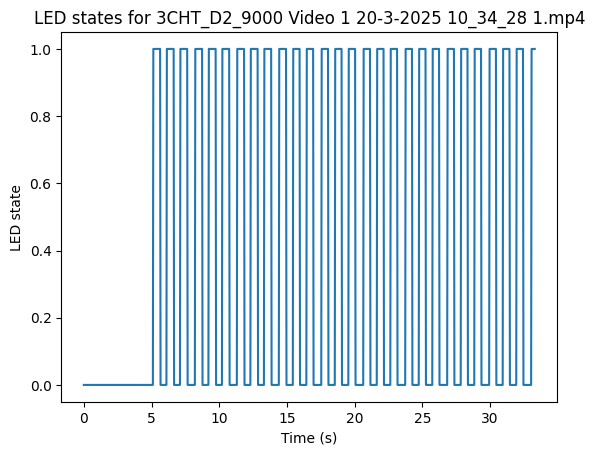

In [15]:
plt.plot(timestamps[:1000], states[:1000])
plt.xlabel("Time (s)")
plt.ylabel("LED state")
plt.title(f"LED states for {example_key}")
plt.show()

## 6. Check first and last LED 

In [16]:
## First LED
first_idx = next((i for i, s in enumerate(states) if s == 1), None)

if first_idx is not None:
    first_time = timestamps[first_idx]
    print("First LED ON at:", first_time, "seconds")
else:
    print("No LED ON found")


## LAST LED
indices = [i for i, s in enumerate(states) if s == 1]

if indices:
    last_idx = indices[-1]
    last_time = last_idx / fps
    print("Last LED ON at:", last_time, "seconds")
else:
    print("No LED ON found")

First LED ON at: 5.133333333333334 seconds
Last LED ON at: 606.4 seconds


## 7. Check first and last LED for all keys in file

In [17]:
results = {}

for video_key, states in led_states.items():

    # find first index where LED == 1
    first_idx = next((i for i, s in enumerate(states) if s == 1), None)

    # find last index where LED == 1
    last_idx = next((i for i in range(len(states)-1, -1, -1) if states[i] == 1), None)

    if first_idx is not None and last_idx is not None:
        first_time = first_idx / fps
        last_time = last_idx / fps

        results[video_key] = {
            "first_idx": first_idx,
            "last_idx": last_idx,
            "first_time": first_time,
            "last_time": last_time
        }

        print(f"{video_key}")
        print(f"  First LED ON: {first_time:.3f} s")
        print(f"  Last LED ON:  {last_time:.3f} s")

    else:
        print(f"{video_key} -> No LED detected")

3CHT_D1_9000 Video 1 19-3-2025 10_20_02 1.mp4 -> No LED detected
3CHT_D1_8997 Video 1 19-3-2025 09_53_46 1.mp4 -> No LED detected
3CHT_D3_8992 Video 1 21-3-2025 09_17_09 1.mp4
  First LED ON: 3.033 s
  Last LED ON:  604.300 s
3CHT_D2_8997 Video 1 20-3-2025 10_11_12 1.mp4
  First LED ON: 4.433 s
  Last LED ON:  605.700 s
3CHT_D3_9000 Video 1 21-3-2025 10_32_51 1.mp4
  First LED ON: 3.500 s
  Last LED ON:  36.000 s
3CHT_D1_8992 Video 1 19-3-2025 09_07_16 1.mp4 -> No LED detected
3CHT_D3_8997 Video 1 21-3-2025 10_07_00 1.mp4
  First LED ON: 3.200 s
  Last LED ON:  46.000 s
3CHT_D1_8985 Video 1 19-3-2025 09_30_37 1.mp4 -> No LED detected
3CHT_D2_8985 Video 1 20-3-2025 09_45_50 1.mp4
  First LED ON: 3.900 s
  Last LED ON:  37.000 s
3CHT_D2_8992 Video 1 20-3-2025 09_29_34 1.mp4
  First LED ON: 4.000 s
  Last LED ON:  605.267 s
3CHT_D2_9000 Video 1 20-3-2025 10_34_28 1.mp4
  First LED ON: 5.133 s
  Last LED ON:  606.400 s
3CHT_D3_8985 Video 1 21-3-2025 09_36_31 1.mp4
  First LED ON: 4.333 s
 